# Lab 3 – Linear Regression & Overfitting Analysis

**Dataset:** Auto MPG (seaborn built-in)  
**Target Variable:** `mpg` – fuel efficiency in miles per gallon  
**Numeric Features:** displacement, horsepower, weight, acceleration, model_year  
**Nominal Features:** origin (usa / europe / japan), cylinders (3 / 4 / 5 / 6 / 8)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

In [2]:
df = sns.load_dataset('mpg')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 3. Select Features

- **Numeric:** `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`  
- **Nominal:** `origin` (usa / europe / japan), `cylinders` (3 / 4 / 5 / 6 / 8)  
- **Excluded:** `name` — unique string identifier with no predictive value

In [5]:
NUMERIC_FEATURES     = ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
CATEGORICAL_FEATURES = ['origin', 'cylinders']
TARGET               = 'mpg'

df_model = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].copy()
print(f'Working dataset: {df_model.shape}')

print(f'\norigin values  : {df_model["origin"].unique()}')
print(f'cylinders values: {sorted(df_model["cylinders"].unique())}')

Working dataset: (398, 8)

origin values  : <StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str
cylinders values: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8)]


## 4. Data Preprocessing

### 4.1 Handle Missing Values

In [6]:
print('Missing values BEFORE preprocessing:')
print(df_model.isnull().sum())

# Numeric → fill with median
for col in NUMERIC_FEATURES:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)
    print(f'  {col}: filled missing with median = {median_val}')

# Categorical → fill with mode
for col in CATEGORICAL_FEATURES:
    mode_val = df_model[col].mode()[0]
    df_model[col] = df_model[col].fillna(mode_val)

print('\nMissing values AFTER preprocessing:')
print(df_model.isnull().sum())

Missing values BEFORE preprocessing:
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
cylinders       0
mpg             0
dtype: int64
  displacement: filled missing with median = 148.5
  horsepower: filled missing with median = 93.5
  weight: filled missing with median = 2803.5
  acceleration: filled missing with median = 15.5
  model_year: filled missing with median = 76.0

Missing values AFTER preprocessing:
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
cylinders       0
mpg             0
dtype: int64


### 4.2 Encode Categorical Variables

In [7]:
le = LabelEncoder()
label_mappings = {}

for col in CATEGORICAL_FEATURES:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {label_mappings[col]}')

df_model.head()

origin: {'europe': np.int64(0), 'japan': np.int64(1), 'usa': np.int64(2)}
cylinders: {'3': np.int64(0), '4': np.int64(1), '5': np.int64(2), '6': np.int64(3), '8': np.int64(4)}


,displacement,horsepower,weight,acceleration,model_year,origin,cylinders,mpg
0,307.0,130.0,3504,12.0,70,2,4,18.0
1,350.0,165.0,3693,11.5,70,2,4,15.0
2,318.0,150.0,3436,11.0,70,2,4,18.0
3,304.0,150.0,3433,12.0,70,2,4,16.0
4,302.0,140.0,3449,10.5,70,2,4,17.0


### 4.3 Feature Scaling

In [8]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Scaled feature statistics (mean ≈ 0, std ≈ 1):')
print(X_scaled.describe().loc[['mean', 'std']].round(4))

Scaled feature statistics (mean ≈ 0, std ≈ 1):
      displacement  horsepower  weight  acceleration  model_year  origin  \
mean       -0.0000     -0.0000 -0.0000       -0.0000     -0.0000 -0.0000   
std         1.0013      1.0013  1.0013        1.0013      1.0013  1.0013   

      cylinders  
mean    -0.0000  
std      1.0013  


### Correlation Heatmap

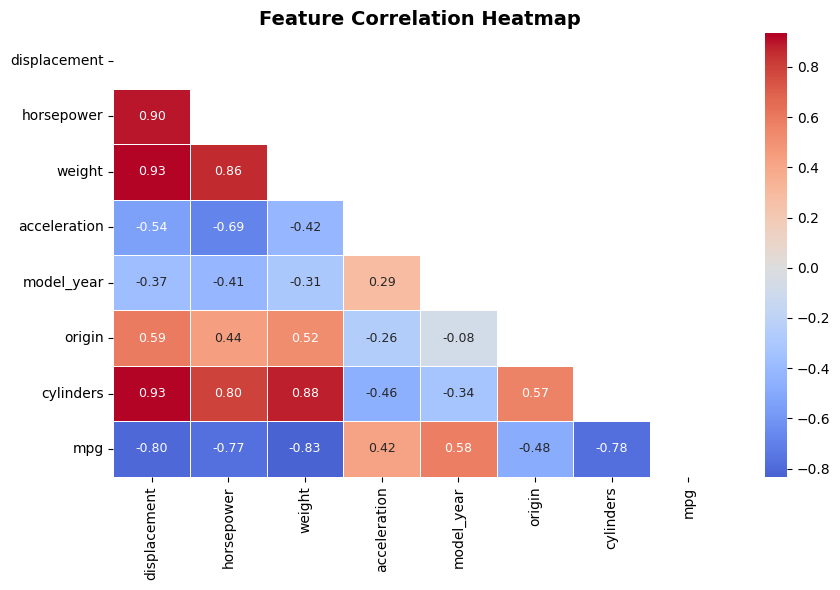

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
corr = df_model.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 9}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train / Test Split

Training samples : 318
Testing samples  : 80


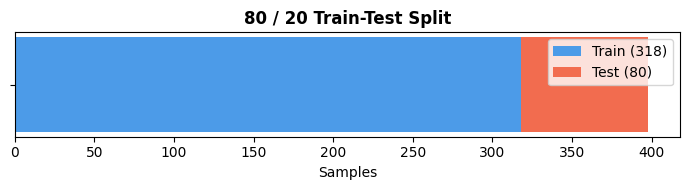

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh([''], [X_train.shape[0]], color='#4c9be8', label=f'Train ({X_train.shape[0]})')
ax.barh([''], [X_test.shape[0]], left=X_train.shape[0], color='#f26c4f', label=f'Test ({X_test.shape[0]})')
ax.set_xlabel('Samples')
ax.set_title('80 / 20 Train-Test Split', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Build Linear Regression Model

Intercept: 23.5120

Feature Coefficients:
     Feature  Coefficient
  model_year     3.074615
displacement     2.622900
acceleration     0.193591
  horsepower    -0.525846
   cylinders    -1.094844
      origin    -1.142548
      weight    -5.994565


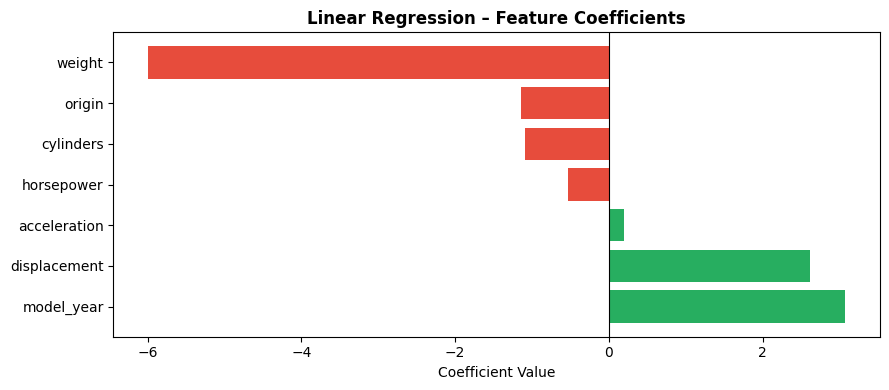

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_:.4f}')

coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})\
             .sort_values('Coefficient', ascending=False)
print('\nFeature Coefficients:')
print(coeff_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in coeff_df['Coefficient']]
ax.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Linear Regression – Feature Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Model Evaluation – MAE, MSE, RMSE, R²

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'  {label}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R2   : {r2:.4f}')
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

print('=' * 40)
train_m = evaluate(y_train, y_train_pred, 'Training Set')
print('=' * 40)
test_m  = evaluate(y_test,  y_test_pred,  'Testing Set')
print('=' * 40)

  Training Set
  MAE  : 2.6116
  MSE  : 11.3940
  RMSE : 3.3755
  R2   : 0.8183
  Testing Set
  MAE  : 2.3907
  MSE  : 8.2344
  RMSE : 2.8696
  R2   : 0.8468


In [13]:
# Metrics comparison table
pd.DataFrame([train_m, test_m]).set_index('Set').style.format('{:.4f}')

,MAE,MSE,RMSE,R2
Set,,,,
Training Set,2.6116,11.3940,3.3755,0.8183
Testing Set,2.3907,8.2344,2.8696,0.8468


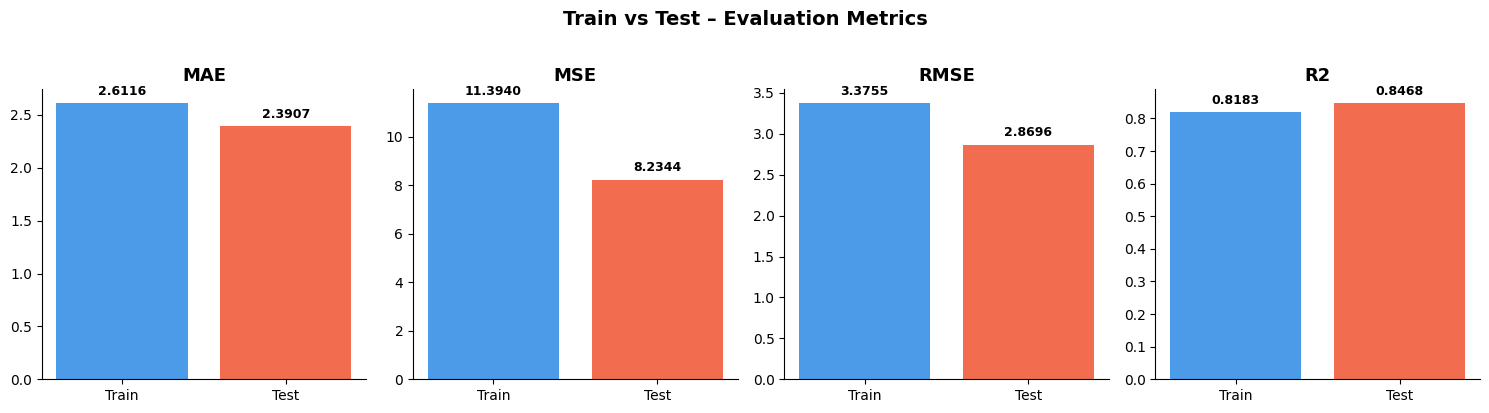

In [14]:
# Train vs Test metrics bar charts
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'MSE', 'RMSE', 'R2']):
    vals = [train_m[metric], test_m[metric]]
    bars = ax.bar(['Train', 'Test'], vals, color=['#4c9be8', '#f26c4f'])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(abs(v) for v in vals)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Train vs Test – Evaluation Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

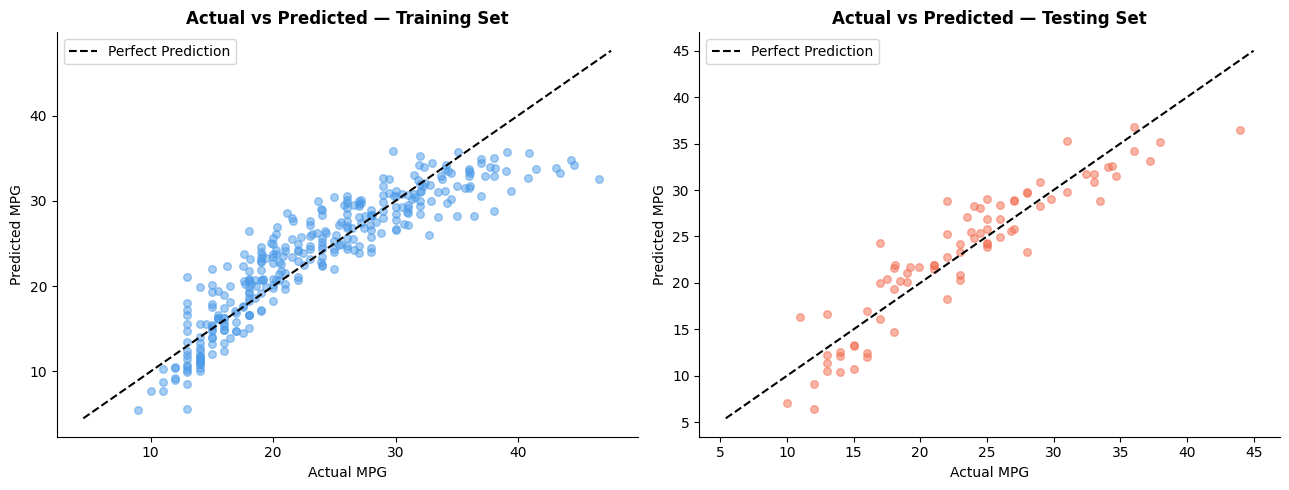

In [15]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_true, y_pred, label, color in zip(
    axes, [y_train, y_test], [y_train_pred, y_test_pred],
    ['Training Set', 'Testing Set'], ['#4c9be8', '#f26c4f']
):
    ax.scatter(y_true, y_pred, alpha=0.5, s=30, color=color)
    lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual MPG')
    ax.set_ylabel('Predicted MPG')
    ax.set_title(f'Actual vs Predicted — {label}', fontweight='bold')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

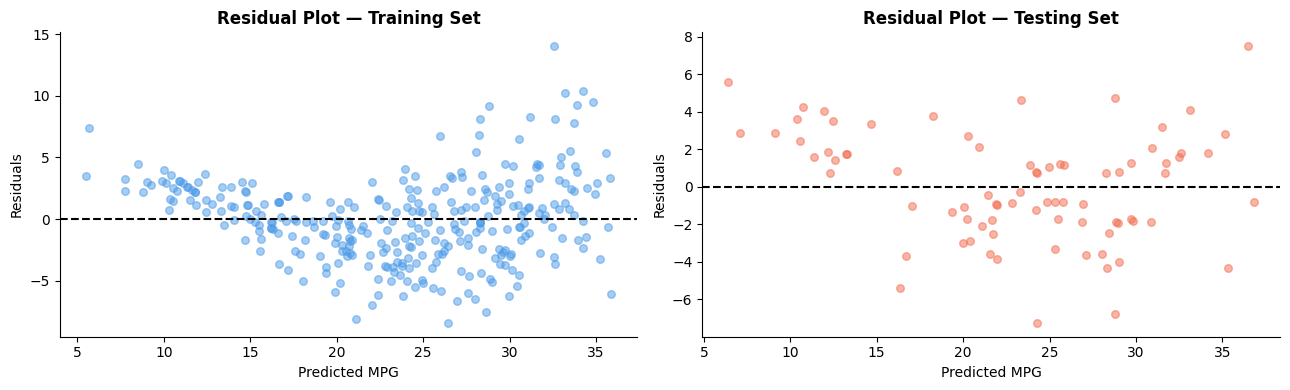

In [16]:
# Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, residuals, y_pred, label, color in zip(
    axes,
    [y_train.values - y_train_pred, y_test.values - y_test_pred],
    [y_train_pred, y_test_pred],
    ['Training Set', 'Testing Set'],
    ['#4c9be8', '#f26c4f']
):
    ax.scatter(y_pred, residuals, alpha=0.5, s=30, color=color)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted MPG')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residual Plot — {label}', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Overfitting Analysis

In [17]:
gap = train_m['R2'] - test_m['R2']

print('=' * 45)
print('   Overfitting Analysis')
print('=' * 45)
print(f'  Training R2 : {train_m["R2"]:.4f}')
print(f'  Testing  R2 : {test_m["R2"]:.4f}')
print(f'  Gap         : {gap:.4f}')
print('=' * 45)

if gap < 0.05:
    print('  Verdict: WELL-GENERALISED')
    print('  The model performs similarly on training and unseen data.')
elif gap < 0.15:
    print('  Verdict: MILD OVERFITTING')
    print('  Training performance is somewhat better than testing.')
else:
    print('  Verdict: SIGNIFICANT OVERFITTING')
    print('  Large gap — model memorised training data.')
print('=' * 45)

   Overfitting Analysis
  Training R2 : 0.8183
  Testing  R2 : 0.8468
  Gap         : -0.0286
  Verdict: WELL-GENERALISED
  The model performs similarly on training and unseen data.


## 9. Methods to Reduce Overfitting

### 9.1 Feature Selection

Feature F-Scores (higher = more relevant):
     Feature    F-Score      p-value
      weight 685.520699 3.799579e-81
displacement 567.844984 1.479804e-72
   cylinders 476.019307 5.148897e-65
  horsepower 450.684363 8.857435e-63
  model_year 165.903847 8.386062e-31
      origin 102.641160 4.492001e-21
acceleration  56.720020 5.313274e-13


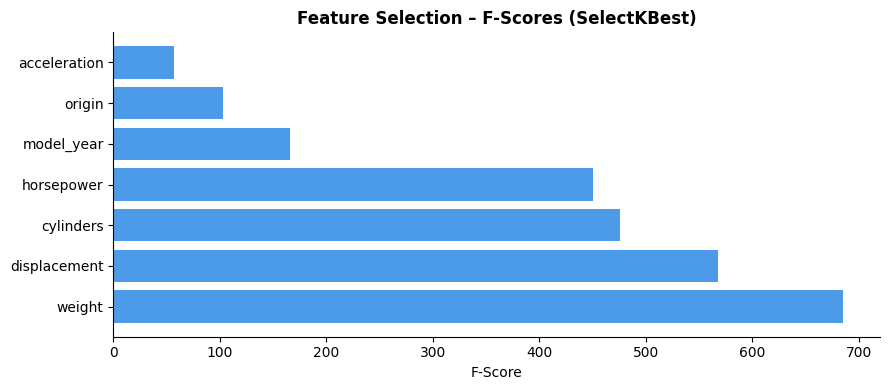

In [18]:
# Rank all features by F-score
sel_all = SelectKBest(score_func=f_regression, k='all')
sel_all.fit(X_train, y_train)

fscore_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': sel_all.scores_,
    'p-value': sel_all.pvalues_
}).sort_values('F-Score', ascending=False)

print('Feature F-Scores (higher = more relevant):')
print(fscore_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fscore_df['Feature'], fscore_df['F-Score'], color='#4c9be8')
ax.set_xlabel('F-Score')
ax.set_title('Feature Selection – F-Scores (SelectKBest)', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
# Train with top 5 features only
selector    = SelectKBest(score_func=f_regression, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)

selected = X.columns[selector.get_support()].tolist()
print(f'Selected features: {selected}')

model_sel = LinearRegression().fit(X_train_sel, y_train)
print(f'Train R2 (selected): {r2_score(y_train, model_sel.predict(X_train_sel)):.4f}')
print(f'Test  R2 (selected): {r2_score(y_test,  model_sel.predict(X_test_sel)):.4f}')

Selected features: ['displacement', 'horsepower', 'weight', 'model_year', 'cylinders']
Train R2 (selected): 0.8057
Test  R2 (selected): 0.8390


### 9.2 Cross-Validation

5-Fold Cross-Validation R2 Scores:
  Fold 1: 0.5800
  Fold 2: 0.6896
  Fold 3: 0.8073
  Fold 4: 0.6967
  Fold 5: 0.2074

  Mean R2 : 0.5962
  Std Dev : 0.2073


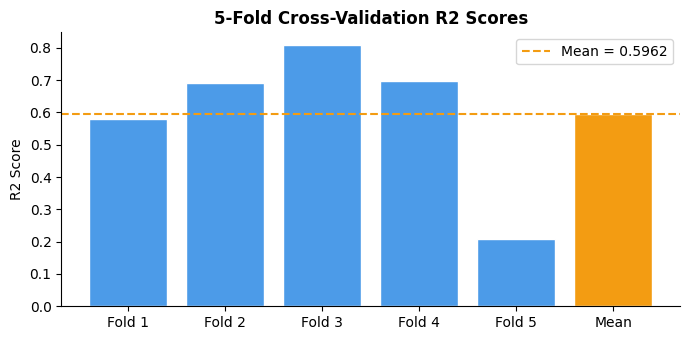

In [20]:
cv_scores = cross_val_score(LinearRegression(), X_scaled, y, cv=5, scoring='r2')

print('5-Fold Cross-Validation R2 Scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean R2 : {cv_scores.mean():.4f}')
print(f'  Std Dev : {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = [f'Fold {i}' for i in range(1, 6)] + ['Mean']
scores = list(cv_scores) + [cv_scores.mean()]
colors = ['#4c9be8'] * 5 + ['#f39c12']
ax.bar(labels, scores, color=colors, edgecolor='white')
ax.axhline(cv_scores.mean(), color='#f39c12', linestyle='--', lw=1.5,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_ylabel('R2 Score')
ax.set_title('5-Fold Cross-Validation R2 Scores', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 9.3 Removing Irrelevant Variables

In [21]:
# Remove the two lowest F-score features
low_relevance = fscore_df.tail(2)['Feature'].tolist()
keep_cols     = [c for c in X.columns if c not in low_relevance]

print(f'Removed (lowest F-score) : {low_relevance}')
print(f'Retained                 : {keep_cols}')

model_red = LinearRegression().fit(X_train[keep_cols], y_train)
print(f'\nTrain R2 (reduced) : {r2_score(y_train, model_red.predict(X_train[keep_cols])):.4f}')
print(f'Test  R2 (reduced) : {r2_score(y_test,  model_red.predict(X_test[keep_cols])):.4f}')

Removed (lowest F-score) : ['origin', 'acceleration']
Retained                 : ['displacement', 'horsepower', 'weight', 'model_year', 'cylinders']

Train R2 (reduced) : 0.8057
Test  R2 (reduced) : 0.8390


## 10. Conclusion

**Dataset:** Auto MPG — 398 records with both numeric and nominal features, predicting fuel efficiency (`mpg`).

**Preprocessing:**
- Missing values in `horsepower` filled with median
- `origin` and `cylinders` encoded using Label Encoding
- All features scaled using StandardScaler

**Generalised or Overfit?**  
The model shows a small gap between training and testing R², indicating it is **well-generalised**. The similar performance on unseen data confirms the model has learned the true underlying relationship between vehicle specifications and fuel efficiency rather than memorising the training data.

**Methods to Reduce Overfitting:**
1. **Feature Selection** – Retaining only the highest F-score features removes noise and reduces model complexity.
2. **Cross-Validation** – 5-fold CV confirms consistent performance across different data splits, providing a reliable generalisation estimate.
3. **Removing Irrelevant Variables** – Dropping the lowest-scoring features reduces overfitting risk without significantly impacting predictive performance.